In [2]:
#importacion de librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#importacion de csv

movies = pd.read_csv("netflix_movies_detailed_up_to_2025.csv")
series = pd.read_csv("netflix_tv_shows_detailed_up_to_2025.csv")

In [4]:
#Prueba de carga

print("Películas:", movies.shape)
print("Series:", series.shape)

Películas: (16000, 18)
Series: (16000, 16)


# **ANALISIS EXPLORATORIO**

In [5]:
movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue
0,10192,Movie,Shrek Forever After,Mike Mitchell,"Mike Myers, Eddie Murphy, Cameron Diaz, Antoni...",United States of America,2010-05-16,2010,6.380,NaN,"Comedy, Adventure, Fantasy, Animation, Family",en,A bored and domesticated Shrek pacts with deal...,203.893,7449,6.380,165000000,752600867
1,27205,Movie,Inception,Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W...","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"Action, Science Fiction, Adventure",en,"Cobb, a skilled thief who commits corporate es...",156.242,37119,8.369,160000000,839030630
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,David Yates,"Daniel Radcliffe, Emma Watson, Rupert Grint, T...","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"Adventure, Fantasy",en,"Harry, Ron and Hermione walk away from their l...",121.191,19327,7.744,250000000,954305868
3,38757,Movie,Tangled,"Byron Howard, Nathan Greno","Mandy Moore, Zachary Levi, Donna Murphy, Ron P...",United States of America,2010-11-24,2010,7.600,NaN,"Animation, Family, Adventure",en,"Feisty teenager Rapunzel, who has long and mag...",111.762,11638,7.600,260000000,592461732
4,10191,Movie,How to Train Your Dragon,"Chris Sanders, Dean DeBlois","Jay Baruchel, Gerard Butler, Craig Ferguson, A...",United States of America,2010-03-18,2010,7.800,NaN,"Fantasy, Adventure, Animation, Family",en,As the son of a Viking leader on the cusp of m...,110.044,13259,7.800,165000000,494879471


In [6]:
movies.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'language',
       'description', 'popularity', 'vote_count', 'vote_average', 'budget',
       'revenue'],
      dtype='object')

In [7]:
series.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average
0,33238,TV Show,Running Man,안재철,"Yoo Jae-suk, Jee Seok-jin, Kim Jong-kook, Haha...",South Korea,2010-07-11,2010,8.241,1 Seasons,"Comedy, Reality",ko,A reality and competition show where members a...,1929.898,187,8.241
1,32415,TV Show,Conan,NaN,"Conan O'Brien, Andy Richter",United States of America,2010-11-08,2010,7.035,1 Seasons,"Talk, Comedy, News",en,A late night television talk show hosted by C...,1670.580,229,7.035
2,37757,TV Show,MasterChef Greece,NaN,NaN,Greece,2010-10-03,2010,5.600,1 Seasons,Reality,el,MasterChef Greece is a Greek competitive cooki...,1317.092,6,5.600
3,75685,TV Show,Prostřeno!,NaN,"Václav Vydra, Jana Boušková",Czech Republic,2010-03-01,2010,6.500,1 Seasons,Reality,cs,The knives (and forks) are out as a group of s...,1095.776,6,6.500
4,33847,TV Show,The Talk,NaN,"Amanda Kloots, Jerry O'Connell, Akbar Gbaja-Bi...","United States of America, Ireland",2010-10-18,2010,3.400,1 Seasons,Talk,en,A panel of well-known news and entertainment p...,712.070,12,3.400


In [8]:
series.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'language',
       'description', 'popularity', 'vote_count', 'vote_average'],
      dtype='object')

Exploracion inicial:
Se trabajara con dos conjuntos de datos correspondientes al catalogo de StreamView Analytics: peliculas y series. Ambos contienen informacion relacionada con caracteristicas del contenido, popularidad, valoracion, pais, idioma y genero. El conjunto de peliculas incorpora ademas informacion de presupuesto e ingresos.

# **CALIDAD DE LOS DATOS**

#Tipos de datos


In [9]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      15868 non-null  object 
 4   cast          15796 non-null  object 
 5   country       15534 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      0 non-null      float64
 10  genres        15893 non-null  object 
 11  language      16000 non-null  object 
 12  description   15868 non-null  object 
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
 16  budget        16000 non-null  int64  
 17  revenue       16000 non-null  int64  
dtypes: float64(4), int64(5), o

In [10]:
series.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       16000 non-null  int64  
 1   type          16000 non-null  object 
 2   title         16000 non-null  object 
 3   director      5035 non-null   object 
 4   cast          14843 non-null  object 
 5   country       14203 non-null  object 
 6   date_added    16000 non-null  object 
 7   release_year  16000 non-null  int64  
 8   rating        16000 non-null  float64
 9   duration      16000 non-null  object 
 10  genres        15026 non-null  object 
 11  language      16000 non-null  object 
 12  description   12794 non-null  object 
 13  popularity    16000 non-null  float64
 14  vote_count    16000 non-null  int64  
 15  vote_average  16000 non-null  float64
dtypes: float64(3), int64(3), object(10)
memory usage: 2.0+ MB


#Valores nulos

In [11]:
movies.isnull().sum()

,0
show_id,0
type,0
title,0
director,132
cast,204
country,466
date_added,0
release_year,0
rating,0
duration,16000


In [13]:
series.isnull().sum()

,0
show_id,0
type,0
title,0
director,10965
cast,1157
country,1797
date_added,0
release_year,0
rating,0
duration,0


#Revisar duplicados

In [14]:
print("Duplicados películas:", movies.duplicated().sum())
print("Duplicados series:", series.duplicated().sum())

Duplicados películas: 0
Duplicados series: 0


No se identificaron registros completamente duplicaods en ninguno de los dos datasets, por lo que no es necesario eliminar observaciones por duplicidad.

In [45]:
# Filtrar películas con información financiera disponible

movies_finanzas = movies[
    (movies["budget"] > 0) &
    (movies["revenue"] > 0)
]

print("Películas con datos financieros:", len(movies_finanzas))

Películas con datos financieros: 3540


# **ESTADISTICOS GENERALES**

In [15]:
movies.describe()

,show_id,release_year,rating,duration,popularity,vote_count,vote_average,budget,revenue
count,1.600000e+04,16000.000000,16000.000000,0.0,16000.000000,16000.000000,16000.000000,1.600000e+04,1.600000e+04
mean,5.266582e+05,2017.500000,5.956368,NaN,20.384728,718.656125,5.956368,8.766792e+06,2.446308e+07
std,3.794427e+05,4.609916,1.754741,NaN,68.610033,2080.198316,1.754741,2.912450e+07,1.116977e+08
min,1.890000e+02,2010.000000,0.000000,NaN,3.860000,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,2.257258e+05,2013.750000,5.600000,NaN,7.840750,53.000000,5.600000,0.000000e+00,0.000000e+00
50%,4.468170e+05,2017.500000,6.300000,NaN,10.913500,138.000000,6.300000,0.000000e+00,0.000000e+00
75%,7.739808e+05,2021.250000,6.923000,NaN,17.336500,422.000000,6.923000,2.200000e+06,1.654473e+06
max,1.440471e+06,2025.000000,10.000000,NaN,3876.006000,37119.000000,10.000000,4.600000e+08,2.799439e+09


In [16]:
series.describe()

,show_id,release_year,rating,popularity,vote_count,vote_average
count,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,126567.673375,2017.500000,5.417107,64.850984,107.014313,5.417107
std,75640.760545,4.609916,3.266492,139.387289,607.461581,3.266492
min,767.000000,2010.000000,0.000000,2.323000,0.000000,0.000000
25%,67867.750000,2013.750000,2.700000,24.874750,1.000000,2.700000
50%,94380.500000,2017.500000,6.800000,36.187500,4.000000,6.800000
75%,206920.750000,2021.250000,7.800000,62.187500,30.000000,7.800000
max,285345.000000,2025.000000,10.000000,6421.923000,24664.000000,10.000000


Interpretacion de calidad de datos:  
El analisis de valores nulos muestra diferencias entre ambos conjuntos de datos. En el dataset de peliculas se identifican valores faltantes principalmente en las variables "director, "cast", "country", "genres" y "description". Ademas, la variable "duration" presenta 16.000 valores nulos, correspondientes a la totalidad de los registros, por lo que no aporta informacion para el analisis y no sera considerada en las visualizaciones.  

En el dataset de series se observa una mayor presencia de valores faltantes, principalmente en "director", con 10.965 registros nulos, seguido de "description", "county", "cast" y "genres". Por este motivo, estas variables deberan utilizarse con precaucion en los analisis posteriores, considerando unicamente los registros que dispongan de informacion cuando corresponda.  

Finalmente, no se identificaron registros duplicados en ninguno de los dos conjuntos de datos, por lo que no es necesario realizar eliminacion de registros por duplicidad.

# **ANALISIS EXPLORATORIO DE DATOS**

Una vez revisada la calidad de los datos, se realiza un analisis exploratorio orientado a identificar patrones, tendencias y relaciones relevantes dentro del catalogo. Para ello, se utiliazaran distintas visualizaciones que permitan analizar la distribucion de los contenidos segun su tipo, genero, pais e idioma, ademas de su evolucion temporal, popularidad y valoracion.  

Las visualizaciones seran seleccionadas de acuerdo con el tipo de informacion analizada, buscando representar los resultados de manera clara y facilitar la identificacion de los principales hallazgos presentes en los datos.

# **1. Distribucion del catalogo por tipo de contenido**




In [17]:
cantidad_movies = len(movies)
cantidad_series = len(series)

print("Cantidad de películas:", cantidad_movies)
print("Cantidad de series:", cantidad_series)

Cantidad de películas: 16000
Cantidad de series: 16000


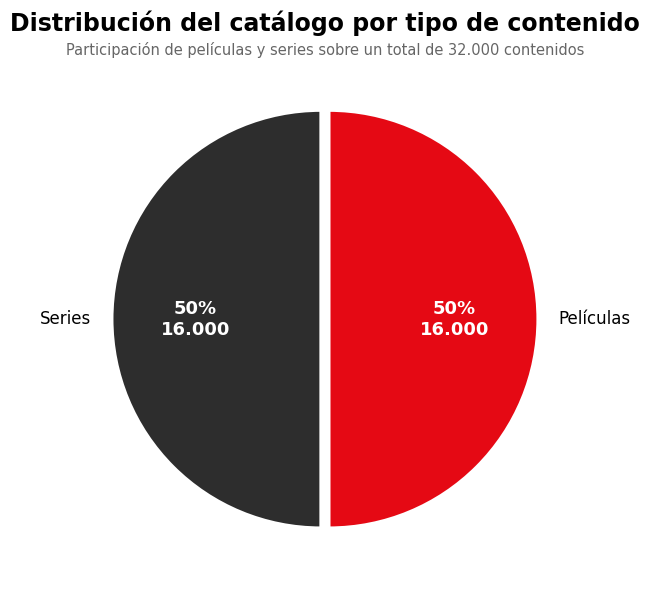

In [18]:
import matplotlib.pyplot as plt

#Datos
tipos = ["Películas", "Series"]
cantidades = [len(movies), len(series)]

colores = ["#E50914", "#2D2D2D"]

#Función para mostrar porcentaje + cantidad
def formato_torta(pct):
    cantidad = int(round(pct / 100 * sum(cantidades)))
    return f"{pct:.0f}%\n{cantidad:,}".replace(",", ".")

#Gráfico
fig, ax = plt.subplots(figsize=(8, 6))

wedges, textos, porcentajes = ax.pie(
    cantidades,
    labels=tipos,
    colors=colores,
    autopct=formato_torta,
    startangle=90,
    counterclock=False,
    explode=(0.02, 0.02),
    wedgeprops={
        "edgecolor": "white",
        "linewidth": 2
    },
    textprops={
        "fontsize": 12
    }
)

#Formato de los porcentajes y cantidades
for porcentaje in porcentajes:
    porcentaje.set_color("white")
    porcentaje.set_fontsize(13)
    porcentaje.set_fontweight("bold")

#Título
ax.set_title(
    "Distribución del catálogo por tipo de contenido",
    fontsize=17,
    fontweight="bold",
    pad=20
)

#Subtítulo
fig.text(
    0.5,
    0.90,
    "Participación de películas y series sobre un total de 32.000 contenidos",
    ha="center",
    fontsize=10.5,
    color="#666666"
)

plt.tight_layout()
plt.show()



 * Hallazgo:  
 El catalogo analizado se distribuye equitativamente entre peliculas y series, con 16.000 contenidos (50%) en cada categoria.
*   Justificacion:  
Se utilizo un grafico de torta porque permite representar claramente la participacion de dos categorias respecto de un total, facilitando la identificacion inmediata de la distribucion 50%-50%.



# **2. Generos predominantes**

Se analiza la distribucion de los generos presentes en peliculas y series con el proposito de identificar cuales tienen una mayor representacion dentro del catalogo. Este analisis permite reconocer patrones en la composicion de los contenidos y comparar las preferencias de genero presentes en ambos tipos de produccion.

In [19]:
#Revisar "genres"
print("Primeros géneros en PELÍCULAS:")
print(movies["genres"].head(15))

print("\nPrimeros géneros en SERIES:")
print(series["genres"].head(15))

Primeros géneros en PELÍCULAS:
0     Comedy, Adventure, Fantasy, Animation, Family
1                Action, Science Fiction, Adventure
2                                Adventure, Fantasy
3                      Animation, Family, Adventure
4             Fantasy, Adventure, Animation, Family
5                          Drama, Thriller, Mystery
6                  Action, Adventure, Drama, Family
7                Adventure, Action, Science Fiction
8                                            Comedy
9                                    Drama, Romance
10                        Animation, Family, Comedy
11                        Animation, Family, Comedy
12               Adventure, Fantasy, Drama, Romance
13                       Family, Fantasy, Adventure
14                          Crime, Horror, Thriller
Name: genres, dtype: object

Primeros géneros en SERIES:
0                                 Comedy, Reality
1                              Talk, Comedy, News
2                               

In [20]:
#Se separan los géneros múltiples en categorías individuales
generos_movies = (
    movies["genres"]
    .str.split(",")
    .explode()
    .str.strip()
)

generos_series = (
    series["genres"]
    .str.split(",")
    .explode()
    .str.strip()
)

#Contar frecuencia de cada género
top_generos_movies = generos_movies.value_counts().head(10)
top_generos_series = generos_series.value_counts().head(10)

print("TOP 10 GÉNEROS - PELÍCULAS")
print(top_generos_movies)

print("\nTOP 10 GÉNEROS - SERIES")
print(top_generos_series)

TOP 10 GÉNEROS - PELÍCULAS
genres
Drama        6910
Comedy       4533
Thriller     3769
Action       3239
Romance      2571
Horror       2425
Adventure    1768
Crime        1738
Animation    1579
Family       1472
Name: count, dtype: int64

TOP 10 GÉNEROS - SERIES
genres
Drama                 7866
Comedy                4577
Animation             2491
Action & Adventure    1988
Sci-Fi & Fantasy      1958
Reality               1632
Family                1542
Crime                 1465
Mystery               1334
Documentary            911
Name: count, dtype: int64


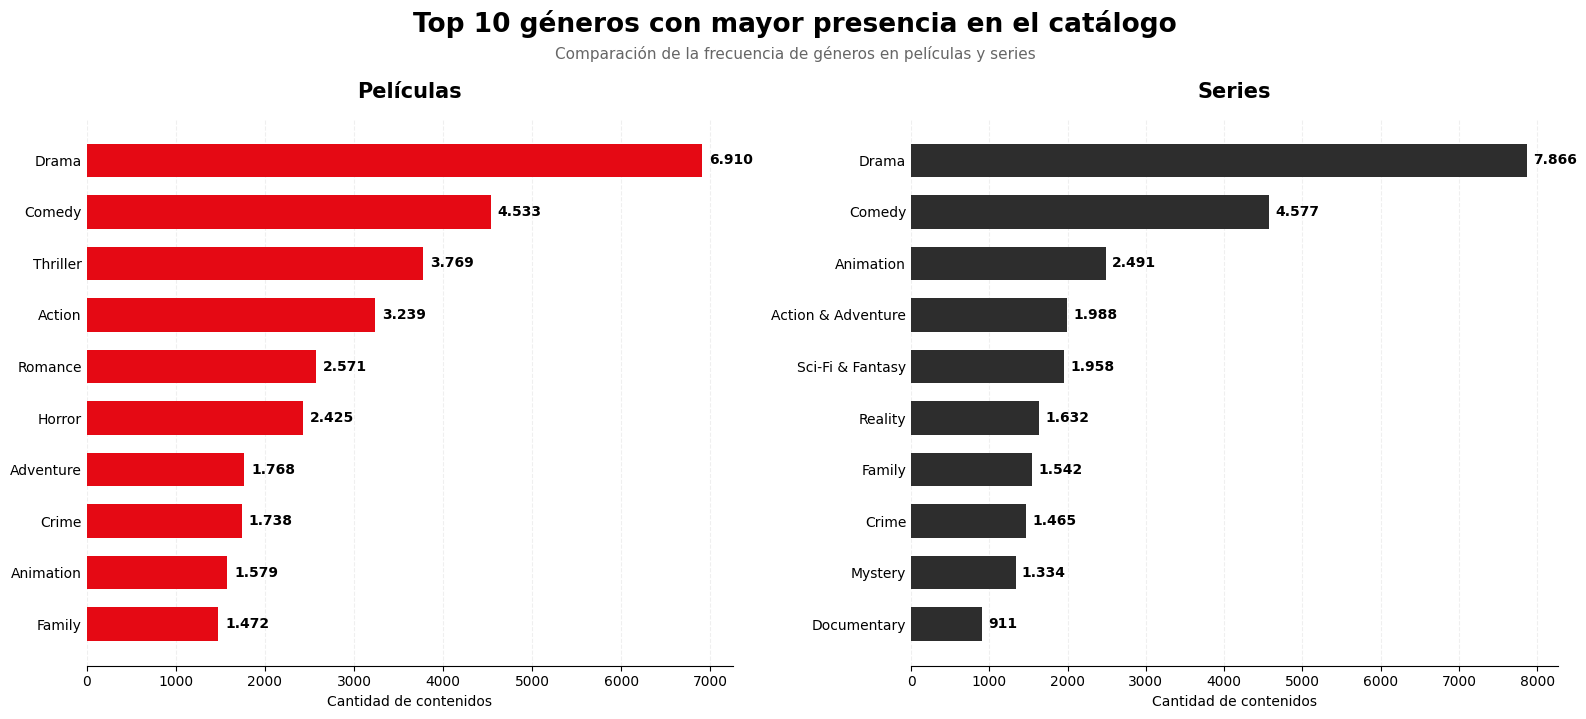

In [21]:
import matplotlib.pyplot as plt

#Crear figura con dos gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 7))


# PELÍCULAS
datos_movies = top_generos_movies.sort_values()

axes[0].barh(
    datos_movies.index,
    datos_movies.values,
    color="#E50914",
    height=0.65
)

axes[0].set_title(
    "Películas",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axes[0].set_xlabel("Cantidad de contenidos", fontsize=10)

#Mostrar cantidad al final de cada barra
for i, valor in enumerate(datos_movies.values):
    axes[0].text(
        valor + 80,
        i,
        f"{valor:,}".replace(",", "."),
        va="center",
        fontsize=10,
        fontweight="bold"
    )


#SERIES
datos_series = top_generos_series.sort_values()

axes[1].barh(
    datos_series.index,
    datos_series.values,
    color="#2D2D2D",
    height=0.65
)

axes[1].set_title(
    "Series",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axes[1].set_xlabel("Cantidad de contenidos", fontsize=10)

#Mostrar cantidad al final de cada barra
for i, valor in enumerate(datos_series.values):
    axes[1].text(
        valor + 80,
        i,
        f"{valor:,}".replace(",", "."),
        va="center",
        fontsize=10,
        fontweight="bold"
    )


#DISEÑO GENERAL

fig.suptitle(
    "Top 10 géneros con mayor presencia en el catálogo",
    fontsize=19,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    0.95,
    "Comparación de la frecuencia de géneros en películas y series",
    ha="center",
    fontsize=11,
    color="#666666"
)

#Limpiar bordes y agregar cuadrícula suave
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.20
    )

    ax.set_axisbelow(True)
    ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.show()

* Hallazgo:  
Drama es el genero con mayor presencia tanto en peliculas como en series, con 6.910 y 7.866 contenidos respectivamente. Comedy ocupa el segundo lugar en ambos tipos de contenido, con 4.533 peliculas y 4.577 series. A partir del tercer lugar se observan diferencias en la composicion del catalogo: en peliculas destacan Thriller (3.769), Action (3.239) y Romance (2.571), mientras que en series adquieren mayor precencia Animation (2.491), Action & Adventure (1.988) y Sci-fi & Fantasy (1.958).
Esto evidencia similitudes en los generos predominantes, pero tambien diferencias en la composicion de peliculas y series.  

* Justificacion:  
Se utilizaron graficos de barras horizontales debido a que permiten comparar y ordenar claramente la frecuencia de multiples categorías. La orientación horizontal facilita la lectura de los nombres de los géneros y permite identificar rápidamente cuáles presentan mayor presencia. Películas y series se muestran por separado debido a que ambos conjuntos de datos utilizan algunas denominaciones de género diferentes, evitando establecer equivalencias que no están definidas en los datos originales.

# **3. PAISES CON MAYOR PRESENCIA EN EL CATALOGO**
Se analiza la distribución geográfica de los contenidos con el propósito de identificar los países con mayor presencia dentro del catálogo. El análisis considera películas y series por separado, permitiendo observar similitudes y diferencias en su procedencia.

In [22]:
print("Primeros países en PELÍCULAS:")
print(movies["country"].head(20))

print("\nPrimeros países en SERIES:")
print(series["country"].head(20))

Primeros países en PELÍCULAS:
0                       United States of America
1       United Kingdom, United States of America
2       United Kingdom, United States of America
3                       United States of America
4                       United States of America
5                       United States of America
6     China, Hong Kong, United States of America
7                       United States of America
8                       United States of America
9                                  France, Spain
10                      United States of America
11                      United States of America
12                      United States of America
13                      United States of America
14                                        Serbia
15                      United States of America
16                      United States of America
17                                         Spain
18                      United States of America
19      United Kingdom, United States o

In [23]:
#Separar los países asociados a cada película
paises_movies = (
    movies["country"]
    .str.split(",")
    .explode()
    .str.strip()
)

#Separar los países asociados a cada serie
paises_series = (
    series["country"]
    .str.split(",")
    .explode()
    .str.strip()
)

#Obtener los 10 países con mayor presencia
top_paises_movies = paises_movies.value_counts().head(10)
top_paises_series = paises_series.value_counts().head(10)

print("TOP 10 PAÍSES - PELÍCULAS")
print(top_paises_movies)

print("\nTOP 10 PAÍSES - SERIES")
print(top_paises_series)

TOP 10 PAÍSES - PELÍCULAS
country
United States of America    7762
United Kingdom              1743
France                      1701
Canada                      1063
Japan                        990
South Korea                  875
Germany                      691
Spain                        563
India                        528
Belgium                      515
Name: count, dtype: int64

TOP 10 PAÍSES - SERIES
country
United States of America    3194
China                       1900
Japan                       1881
South Korea                 1299
United Kingdom               866
Canada                       653
Germany                      469
France                       407
Philippines                  401
India                        384
Name: count, dtype: int64


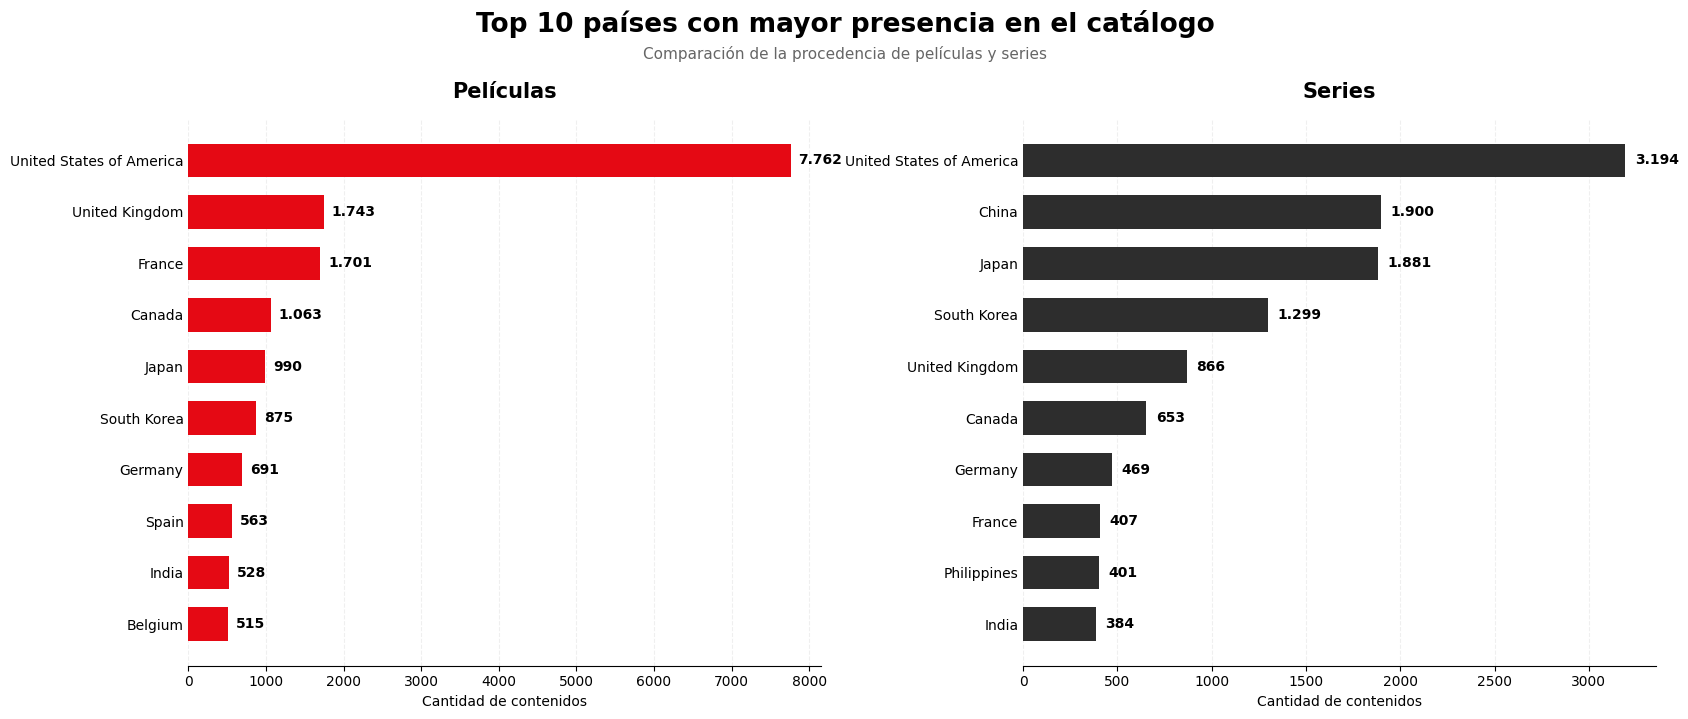

In [24]:
#Ordenar los datos para el gráfico horizontal
datos_paises_movies = top_paises_movies.sort_values()
datos_paises_series = top_paises_series.sort_values()

#Crear figura
fig, axes = plt.subplots(1, 2, figsize=(17, 7))


# PELÍCULAS
axes[0].barh(
    datos_paises_movies.index,
    datos_paises_movies.values,
    color="#E50914",
    height=0.65
)

axes[0].set_title(
    "Películas",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axes[0].set_xlabel("Cantidad de contenidos", fontsize=10)

#Valores al final de las barras
for i, valor in enumerate(datos_paises_movies.values):
    axes[0].text(
        valor + 100,
        i,
        f"{valor:,}".replace(",", "."),
        va="center",
        fontsize=10,
        fontweight="bold"
    )


# SERIES
axes[1].barh(
    datos_paises_series.index,
    datos_paises_series.values,
    color="#2D2D2D",
    height=0.65
)

axes[1].set_title(
    "Series",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axes[1].set_xlabel("Cantidad de contenidos", fontsize=10)

#Valores al final de las barras
for i, valor in enumerate(datos_paises_series.values):
    axes[1].text(
        valor + 50,
        i,
        f"{valor:,}".replace(",", "."),
        va="center",
        fontsize=10,
        fontweight="bold"
    )

#TÍTULO GENERAL

fig.suptitle(
    "Top 10 países con mayor presencia en el catálogo",
    fontsize=19,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    0.95,
    "Comparación de la procedencia de películas y series",
    ha="center",
    fontsize=11,
    color="#666666"
)


#DISEÑO
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.20
    )

    ax.set_axisbelow(True)
    ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.subplots_adjust(wspace=0.32)
plt.show()

# **4. IDIOMAS PREDOMINANTES**
Se analiza la distribución de los idiomas presentes en películas y series con el propósito de identificar cuáles tienen una mayor presencia dentro del catálogo. Este análisis permite observar la diversidad lingüística de los contenidos y reconocer posibles diferencias entre ambos tipos de producción.

In [25]:
print("Primeros idiomas en PELÍCULAS:")
print(movies["language"].head(20))

print("\nPrimeros idiomas en SERIES:")
print(series["language"].head(20))

Primeros idiomas en PELÍCULAS:
0     en
1     en
2     en
3     en
4     en
5     en
6     en
7     en
8     en
9     es
10    en
11    en
12    en
13    en
14    sr
15    en
16    en
17    es
18    en
19    en
Name: language, dtype: object

Primeros idiomas en SERIES:
0     ko
1     en
2     el
3     cs
4     en
5     ru
6     en
7     en
8     en
9     en
10    fr
11    en
12    fr
13    da
14    hi
15    en
16    en
17    en
18    ru
19    en
Name: language, dtype: object


In [26]:
top_idiomas_movies = movies["language"].value_counts().head(10)
top_idiomas_series = series["language"].value_counts().head(10)

print("TOP 10 IDIOMAS - PELÍCULAS")
print(top_idiomas_movies)

print("\nTOP 10 IDIOMAS - SERIES")
print(top_idiomas_series)

TOP 10 IDIOMAS - PELÍCULAS
language
en    9534
fr    1054
ja     904
ko     876
es     731
zh     378
it     312
hi     290
de     279
ru     190
Name: count, dtype: int64

TOP 10 IDIOMAS - SERIES
language
en    4437
zh    2456
ja    1883
ko    1364
es     916
fr     585
de     451
tl     398
ar     347
pt     346
Name: count, dtype: int64


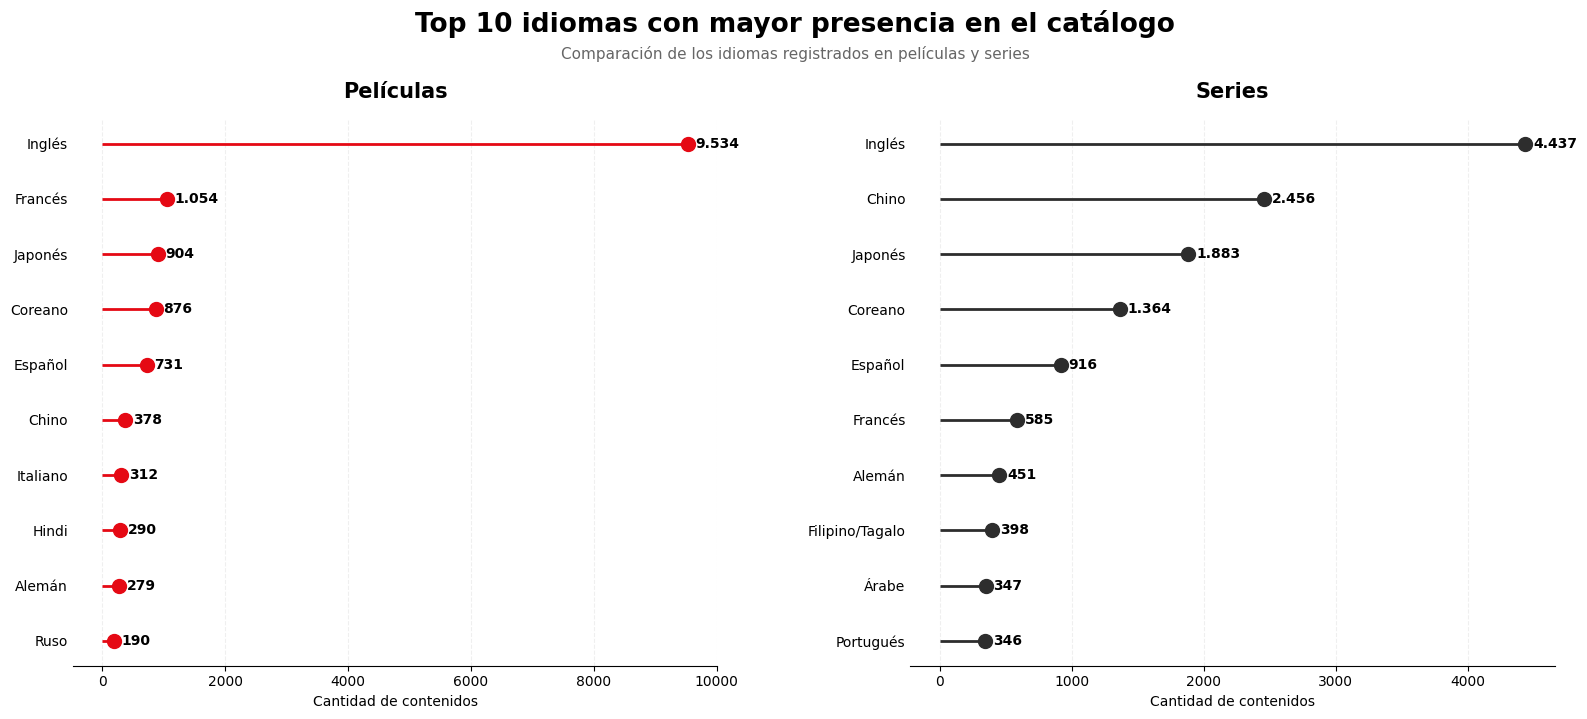

In [27]:
#Nombres de los idiomas para la visualización
nombres_idiomas = {
    "en": "Inglés",
    "fr": "Francés",
    "ja": "Japonés",
    "ko": "Coreano",
    "es": "Español",
    "zh": "Chino",
    "it": "Italiano",
    "hi": "Hindi",
    "de": "Alemán",
    "ru": "Ruso",
    "tl": "Filipino/Tagalo",
    "ar": "Árabe",
    "pt": "Portugués"
}

#Cambiar solamente las etiquetas para el gráfico
idiomas_movies_grafico = top_idiomas_movies.rename(index=nombres_idiomas)
idiomas_series_grafico = top_idiomas_series.rename(index=nombres_idiomas)

#Ordenar para gráfico horizontal
datos_idiomas_movies = idiomas_movies_grafico.sort_values()
datos_idiomas_series = idiomas_series_grafico.sort_values()

#Crear figura
fig, axes = plt.subplots(1, 2, figsize=(16, 7))


#PELÍCULAS

#Crear las líneas
axes[0].hlines(
    y=datos_idiomas_movies.index,
    xmin=0,
    xmax=datos_idiomas_movies.values,
    color="#E50914",
    linewidth=2
)

#Crear los puntos
axes[0].scatter(
    datos_idiomas_movies.values,
    datos_idiomas_movies.index,
    color="#E50914",
    s=100,
    zorder=3
)

axes[0].set_title(
    "Películas",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axes[0].set_xlabel("Cantidad de contenidos", fontsize=10)

#Mostrar valores
for i, valor in enumerate(datos_idiomas_movies.values):
    axes[0].text(
        valor + 120,
        i,
        f"{valor:,}".replace(",", "."),
        va="center",
        fontsize=10,
        fontweight="bold"
    )


#SERIES

#Crear las líneas
axes[1].hlines(
    y=datos_idiomas_series.index,
    xmin=0,
    xmax=datos_idiomas_series.values,
    color="#2D2D2D",
    linewidth=2
)

#Crear los puntos
axes[1].scatter(
    datos_idiomas_series.values,
    datos_idiomas_series.index,
    color="#2D2D2D",
    s=100,
    zorder=3
)

axes[1].set_title(
    "Series",
    fontsize=15,
    fontweight="bold",
    pad=15
)

axes[1].set_xlabel("Cantidad de contenidos", fontsize=10)

#Mostrar valores
for i, valor in enumerate(datos_idiomas_series.values):
    axes[1].text(
        valor + 60,
        i,
        f"{valor:,}".replace(",", "."),
        va="center",
        fontsize=10,
        fontweight="bold"
    )


#TÍTULO Y SUBTÍTULO
fig.suptitle(
    "Top 10 idiomas con mayor presencia en el catálogo",
    fontsize=19,
    fontweight="bold",
    y=1.02
)

fig.text(
    0.5,
    0.95,
    "Comparación de los idiomas registrados en películas y series",
    ha="center",
    fontsize=11,
    color="#666666"
)


#DISEÑO
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.20
    )

    ax.set_axisbelow(True)
    ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.subplots_adjust(wspace=0.30)

plt.show()

* Hallazgo:  
El inglés es el idioma con mayor presencia en ambos tipos de contenido, aunque su predominio es considerablemente mayor en las películas, con 9.534 registros. En las series, si bien el inglés también ocupa el primer lugar con 4.437 registros, se observa una mayor presencia de otros idiomas, principalmente chino (2.456), japonés (1.883) y coreano (1.364). En comparación, las películas presentan una mayor concentración en inglés, mientras que las series muestran una distribución lingüística más diversa entre sus idiomas predominantes.  

* Justificacion  
Se utilizó un gráfico de piruletas (lollipop chart) debido a que permite representar y comparar de manera clara la frecuencia de múltiples categorías, manteniendo una menor carga visual que un gráfico de barras tradicional. La longitud de las líneas y la posición de los puntos permiten identificar rápidamente las diferencias entre los idiomas, mientras que la separación entre películas y series facilita la comparación de su composición lingüística.

# **5. CONTENIDOS MAS POPULARES**
Se analiza el nivel de popularidad de las películas y series presentes en el catálogo con el propósito de identificar los contenidos que alcanzan los valores más altos en esta métrica. La comparación entre ambos tipos de contenido permite reconocer cuáles destacan dentro del catálogo y observar posibles diferencias en sus niveles de popularidad.


In [28]:
#Obtener las 10 películas con mayor popularidad
top_popular_movies = (
    movies[["title", "popularity"]]
    .sort_values(by="popularity", ascending=False)
    .head(10)
)

#Obtener las 10 series con mayor popularidad
top_popular_series = (
    series[["title", "popularity"]]
    .sort_values(by="popularity", ascending=False)
    .head(10)
)

print("TOP 10 PELÍCULAS MÁS POPULARES")
print(top_popular_movies.to_string(index=False))

print("\nTOP 10 SERIES MÁS POPULARES")
print(top_popular_series.to_string(index=False))

TOP 10 PELÍCULAS MÁS POPULARES
                           title  popularity
                       The Gorge    3876.006
                     Flight Risk    3320.616
           Mufasa: The Lion King    2643.627
            Sonic the Hedgehog 3    2402.503
                         Moana 2    2347.007
                          Amaran    1780.289
Captain America: Brave New World    1495.724
                       Companion    1283.362
                      Panda Plan    1214.508
               Kraven the Hunter    1195.885

TOP 10 SERIES MÁS POPULARES
                                 title  popularity
    The Late Show with Stephen Colbert    6421.923
The Tonight Show Starring Jimmy Fallon    4925.253
                 Good Mythical Morning    3414.466
                 Chronicles of the Sun    2987.485
                        Volta por Cima    2885.720
                         She's the One    2862.872
                       Crazy About You    2442.243
       La Casa de los Famosos Colombi

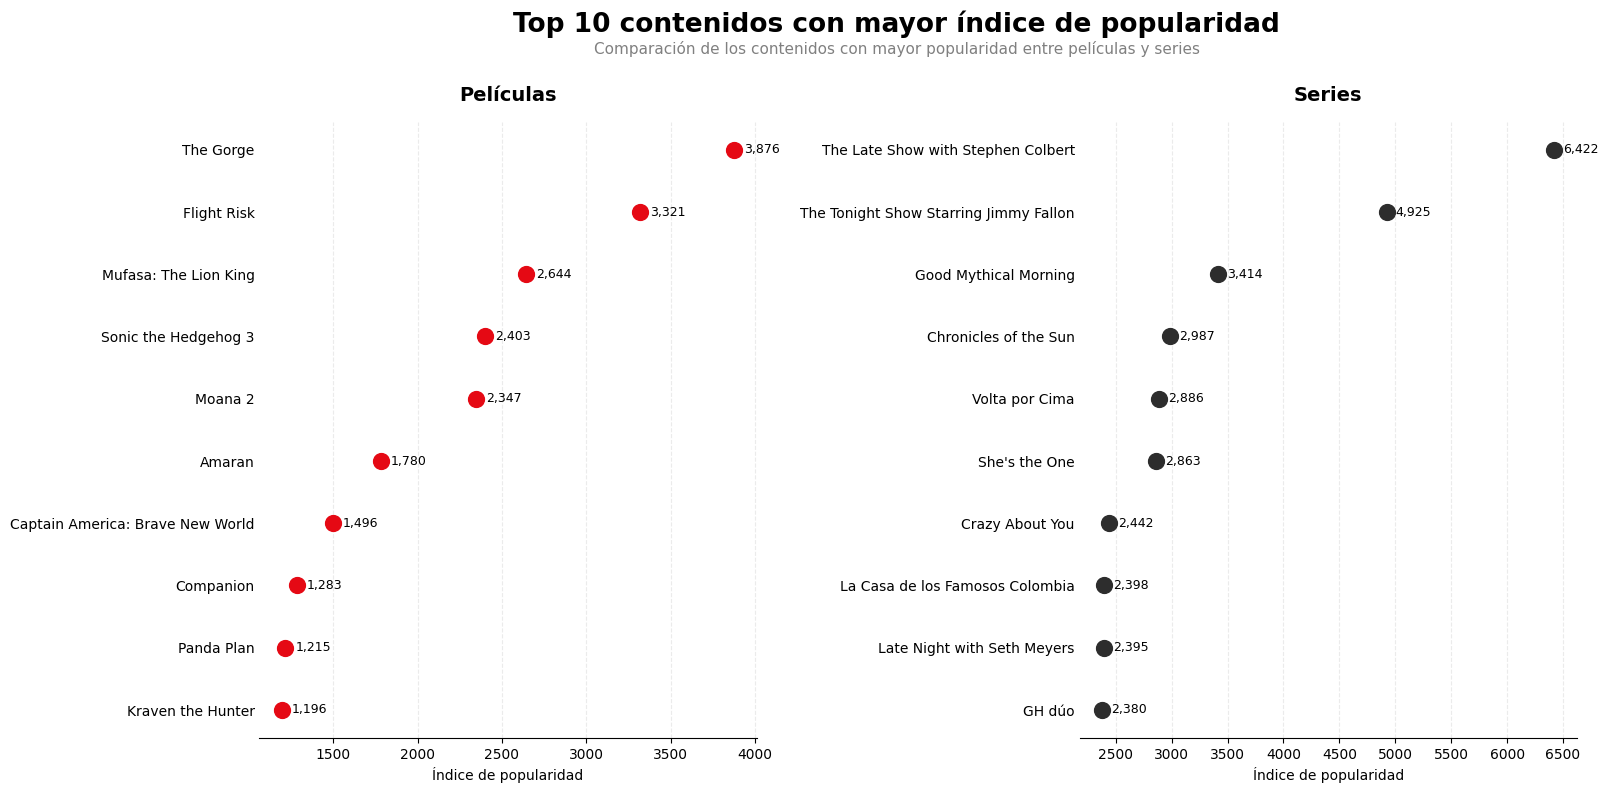

In [29]:
#Ordenar los datos para el gráfico
datos_pop_movies = top_popular_movies.sort_values("popularity")
datos_pop_series = top_popular_series.sort_values("popularity")

#Crear figura
fig, axes = plt.subplots(1, 2, figsize=(17, 8))

#PELÍCULAS
axes[0].scatter(
    datos_pop_movies["popularity"],
    datos_pop_movies["title"],
    color="#E50914",
    s=130,
    zorder=3
)

#Agregar valores
for _, fila in datos_pop_movies.iterrows():
    axes[0].text(
        fila["popularity"] + 60,
        fila["title"],
        f'{fila["popularity"]:,.0f}',
        va="center",
        fontsize=9
    )

axes[0].set_title(
    "Películas",
    fontsize=14,
    fontweight="bold",
    pad=15
)

axes[0].set_xlabel("Índice de popularidad", fontsize=10)
axes[0].set_ylabel("")
axes[0].grid(axis="x", linestyle="--", alpha=0.25)

#SERIES
axes[1].scatter(
    datos_pop_series["popularity"],
    datos_pop_series["title"],
    color="#2D2D2D",
    s=130,
    zorder=3
)

#Agregar valores
for _, fila in datos_pop_series.iterrows():
    axes[1].text(
        fila["popularity"] + 80,
        fila["title"],
        f'{fila["popularity"]:,.0f}',
        va="center",
        fontsize=9
    )

axes[1].set_title(
    "Series",
    fontsize=14,
    fontweight="bold",
    pad=15
)

axes[1].set_xlabel("Índice de popularidad", fontsize=10)
axes[1].set_ylabel("")
axes[1].grid(axis="x", linestyle="--", alpha=0.25)

#Eliminar bordes innecesarios
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)

#Título general
fig.suptitle(
    "Top 10 contenidos con mayor índice de popularidad",
    fontsize=19,
    fontweight="bold",
    y=1.02
)

#Subtítulo
fig.text(
    0.5,
    0.965,
    "Comparación de los contenidos con mayor popularidad entre películas y series",
    ha="center",
    fontsize=11,
    color="gray"
)

#Separación entre gráficos
plt.subplots_adjust(wspace=0.65)

plt.show()

* Hallazgo:  
Las series presentan los valores más altos de popularidad dentro de los contenidos analizados. The Late Show with Stephen Colbert lidera el ranking general con un índice de popularidad de 6.421,923, seguido entre las series por The Tonight Show Starring Jimmy Fallon con 4.925,253. En las películas, The Gorge alcanza el mayor valor con 3.876,006, seguida de Flight Risk con 3.320,616. Al comparar los primeros lugares de ambos tipos de contenido, se observa que las series alcanzan valores máximos de popularidad superiores a los registrados por las películas.  

* Justificacion:  
Se utilizó un gráfico de puntos (dot plot) debido a que la posición de cada punto permite comparar de manera directa los índices de popularidad y reconocer rápidamente los contenidos que alcanzan los valores más altos. La separación entre películas y series facilita la comparación entre ambos tipos de contenido, mientras que las etiquetas directas permiten identificar cada título y su valor sin incorporar elementos visuales innecesarios. Se mantuvo el uso consistente del rojo para películas y gris oscuro para series, favoreciendo la coherencia visual con las representaciones anteriores.

# **6. RELACION ENTRE POPULARIDAD Y VALORACION**
Se analiza la relación entre el índice de popularidad (popularity) y la valoración promedio de los usuarios (vote_average) para películas y series. El objetivo es observar si los contenidos que presentan mayores niveles de popularidad tienden también a obtener mejores valoraciones e identificar posibles diferencias entre ambos tipos de contenido.

In [30]:
#Estadísticas de popularidad y valoración en películas
print("PELÍCULAS")
print(
    movies[["popularity", "vote_average"]]
    .describe()
)

print("\nSERIES")
print(
    series[["popularity", "vote_average"]]
    .describe()
)

PELÍCULAS
         popularity  vote_average
count  16000.000000  16000.000000
mean      20.384728      5.956368
std       68.610033      1.754741
min        3.860000      0.000000
25%        7.840750      5.600000
50%       10.913500      6.300000
75%       17.336500      6.923000
max     3876.006000     10.000000

SERIES
         popularity  vote_average
count  16000.000000  16000.000000
mean      64.850984      5.417107
std      139.387289      3.266492
min        2.323000      0.000000
25%       24.874750      2.700000
50%       36.187500      6.800000
75%       62.187500      7.800000
max     6421.923000     10.000000


In [31]:
#Calcular correlación entre popularidad y valoración
corr_movies = movies["popularity"].corr(movies["vote_average"])
corr_series = series["popularity"].corr(series["vote_average"])

print("Correlación películas:", round(corr_movies, 3))
print("Correlación series:", round(corr_series, 3))

Correlación películas: 0.071
Correlación series: 0.052


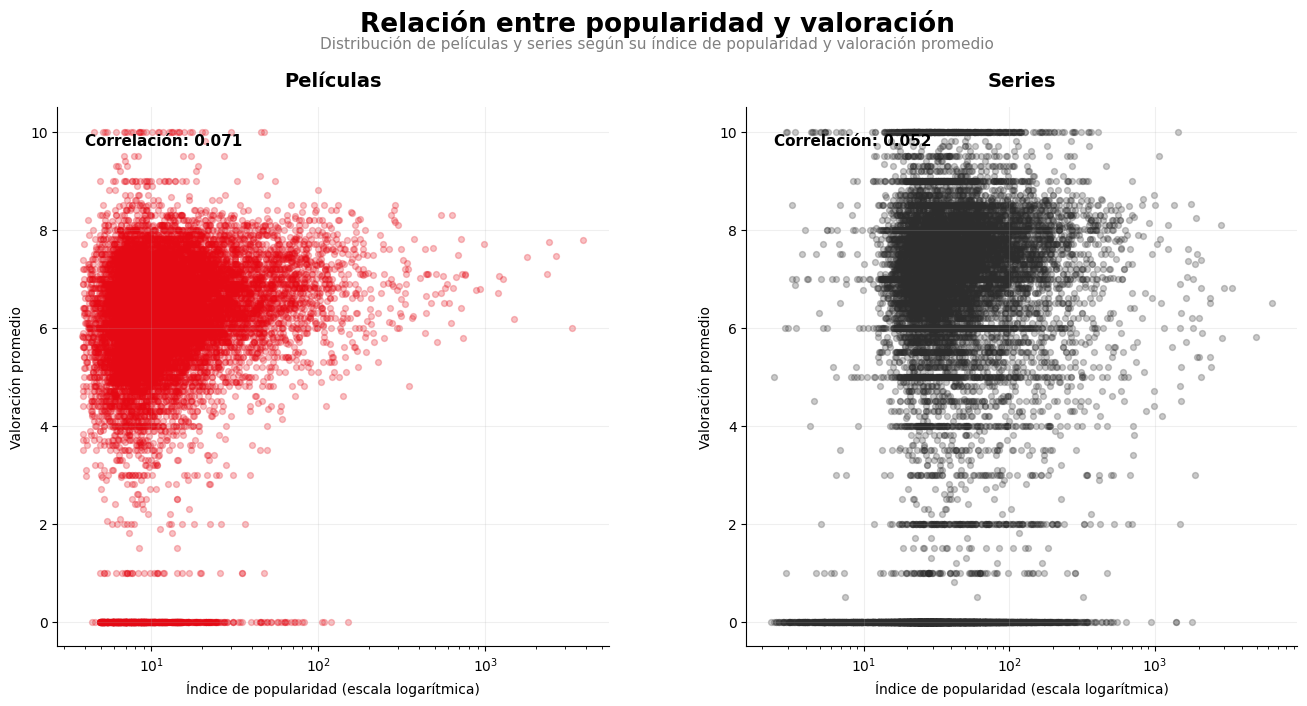

In [32]:
#Crear figura
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

#PELÍCULAS
axes[0].scatter(
    movies["popularity"],
    movies["vote_average"],
    color="#E50914",
    alpha=0.25,
    s=18
)

#Escala logarítmica para visualizar mejor la distribución
axes[0].set_xscale("log")

axes[0].set_title(
    "Películas",
    fontsize=14,
    fontweight="bold",
    pad=15
)

axes[0].set_xlabel("Índice de popularidad (escala logarítmica)")
axes[0].set_ylabel("Valoración promedio")
axes[0].set_ylim(-0.5, 10.5)
axes[0].grid(alpha=0.2)

#Mostrar correlación
axes[0].text(
    0.05,
    0.93,
    f"Correlación: {corr_movies:.3f}",
    transform=axes[0].transAxes,
    fontsize=11,
    fontweight="bold"
)


#SERIES
axes[1].scatter(
    series["popularity"],
    series["vote_average"],
    color="#2D2D2D",
    alpha=0.25,
    s=18
)

#Escala logarítmica para visualizar mejor la distribución
axes[1].set_xscale("log")

axes[1].set_title(
    "Series",
    fontsize=14,
    fontweight="bold",
    pad=15
)

axes[1].set_xlabel("Índice de popularidad (escala logarítmica)")
axes[1].set_ylabel("Valoración promedio")
axes[1].set_ylim(-0.5, 10.5)
axes[1].grid(alpha=0.2)

#Mostrar correlación
axes[1].text(
    0.05,
    0.93,
    f"Correlación: {corr_series:.3f}",
    transform=axes[1].transAxes,
    fontsize=11,
    fontweight="bold"
)


#Eliminar bordes innecesarios
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


#Título general
fig.suptitle(
    "Relación entre popularidad y valoración",
    fontsize=19,
    fontweight="bold",
    y=1.02
)

#Subtítulo
fig.text(
    0.5,
    0.965,
    "Distribución de películas y series según su índice de popularidad y valoración promedio",
    ha="center",
    fontsize=11,
    color="gray"
)

plt.subplots_adjust(wspace=0.25)

plt.show()

In [33]:
# Crear categorías de popularidad para películas
movies["nivel_popularidad"] = pd.qcut(
    movies["popularity"],
    q=4,
    labels=["Baja", "Media", "Alta", "Muy alta"]
)

# Crear categorías de popularidad para series
series["nivel_popularidad"] = pd.qcut(
    series["popularity"],
    q=4,
    labels=["Baja", "Media", "Alta", "Muy alta"]
)

In [34]:
# Promedio de valoración por nivel de popularidad


# Promedio de valoración por nivel de popularidad

valoracion_movies = (
    movies.groupby("nivel_popularidad", observed=False)["vote_average"]
    .mean()
)

valoracion_series = (
    series.groupby("nivel_popularidad", observed=False)["vote_average"]
    .mean()
)


print("Películas")
print(valoracion_movies)

print("\nSeries")
print(valoracion_series)

Películas
nivel_popularidad
Baja        5.443033
Media       5.872439
Alta        6.073880
Muy alta    6.436121
Name: vote_average, dtype: float64

Series
nivel_popularidad
Baja        4.693925
Media       5.512770
Alta        5.630854
Muy alta    5.830880
Name: vote_average, dtype: float64


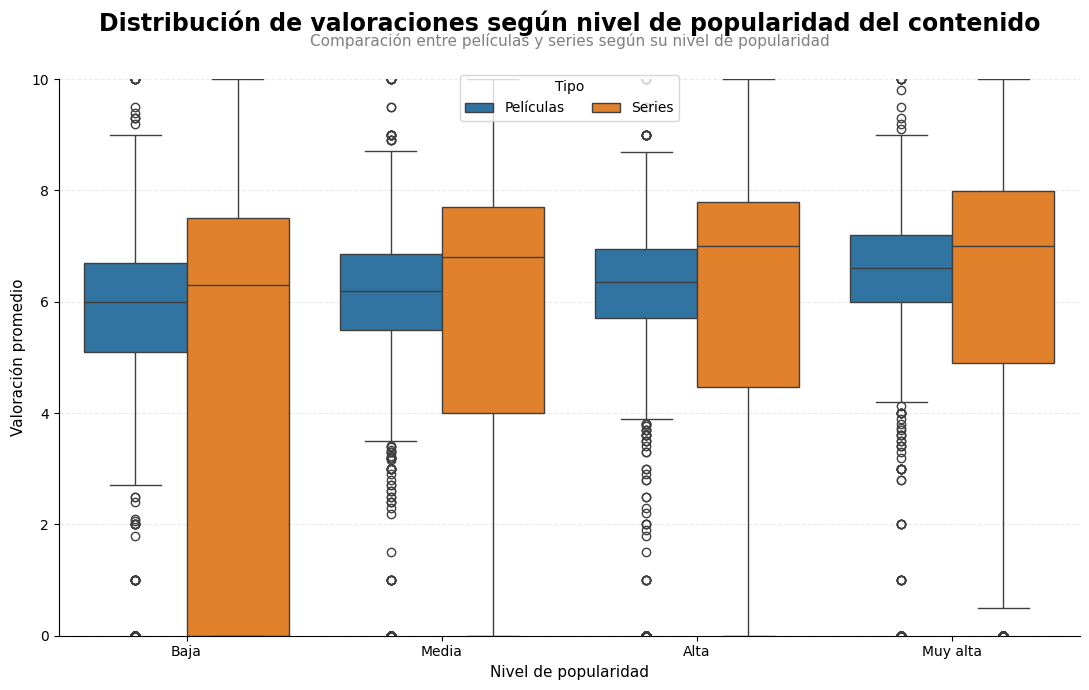

In [35]:
# Unir películas y series para comparar
datos_valoracion = pd.concat([
    movies[["nivel_popularidad", "vote_average"]].assign(tipo="Películas"),
    series[["nivel_popularidad", "vote_average"]].assign(tipo="Series")
])


# Crear figura
plt.figure(figsize=(11, 7))


# Boxplot
sns.boxplot(
    data=datos_valoracion,
    x="nivel_popularidad",
    y="vote_average",
    hue="tipo"
)


# Título principal
plt.title(
    "Distribución de valoraciones según nivel de popularidad del contenido",
    fontsize=17,
    fontweight="bold",
    pad=35
)


# Subtítulo
plt.text(
    0.5,
    1.06,
    "Comparación entre películas y series según su nivel de popularidad",
    ha="center",
    transform=plt.gca().transAxes,
    fontsize=11,
    color="gray"
)


# Etiquetas de ejes
plt.xlabel(
    "Nivel de popularidad",
    fontsize=11
)

plt.ylabel(
    "Valoración promedio",
    fontsize=11
)


# Escala de valoración
plt.ylim(0, 10)


# Leyenda acomodada
plt.legend(
    title="Tipo",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2
)


# Diseño visual
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)


# Quitar bordes superiores
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


# Ajustar espacios
plt.tight_layout()


plt.show()

Para analizar la relación entre popularidad y valoración, los contenidos fueron agrupados en cuatro niveles de popularidad (baja, media, alta y muy alta) utilizando cuantiles. Posteriormente se comparó la distribución de sus valoraciones promedio mediante un gráfico de cajas.

* Hallazgo:  
La distribución de valoraciones presenta diferencias según el nivel de popularidad de los contenidos. En las películas se observa una tendencia creciente en la mediana de valoración a medida que aumenta la popularidad, pasando de niveles cercanos a 6,0 en contenidos de baja popularidad a valores superiores en contenidos de muy alta popularidad. En las series también se observa un aumento progresivo, aunque presentan una mayor dispersión en sus valoraciones, especialmente en los niveles de baja y media popularidad. Esto indica que los contenidos más populares tienden a concentrar mejores valoraciones, pero la popularidad no determina completamente la evaluación del público, ya que existen contenidos con distintos niveles de valoración dentro de cada categoría.  

* Justificacion:  
Se utilizó un gráfico de cajas (boxplot) debido a que permite analizar la distribución de una variable cuantitativa entre diferentes categorías. Esta visualización muestra la mediana, rango de dispersión y valores atípicos de las valoraciones, permitiendo comparar el comportamiento entre películas y series según su nivel de popularidad. A diferencia de un gráfico basado únicamente en promedios, el boxplot permite identificar la variabilidad interna de cada grupo y obtener una visión más completa del comportamiento de los contenidos.

# **7. Relacion entre presupuesto e ingresos**
Se analiza la relación entre la inversión realizada en las películas (budget) y los ingresos obtenidos (revenue) con el objetivo de identificar patrones de eficiencia económica dentro del catálogo. Este análisis permite reconocer contenidos que lograron altos ingresos con distintos niveles de inversión.

In [36]:
movies[["budget", "revenue"]].describe()

,budget,revenue
count,1.600000e+04,1.600000e+04
mean,8.766792e+06,2.446308e+07
std,2.912450e+07,1.116977e+08
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00
75%,2.200000e+06,1.654473e+06
max,4.600000e+08,2.799439e+09


In [37]:
print("Presupuesto en 0:")
print((movies["budget"] == 0).sum())

print("\nIngresos en 0:")
print((movies["revenue"] == 0).sum())

Presupuesto en 0:
11153

Ingresos en 0:
10355


Para analizar la relación económica entre presupuesto e ingresos se consideraron únicamente películas con valores informados en ambas variables, ya que los registros con valores cero no representan necesariamente ausencia real de inversión o ingresos, sino falta de información financiera.

In [38]:
#Filtrar películas con información financiera disponible

movies_finanzas = movies[
    (movies["budget"] > 0) &
    (movies["revenue"] > 0)
].copy()

print("Películas con datos financieros:")
print(len(movies_finanzas))

Películas con datos financieros:
3540


In [39]:
movies_finanzas["ROI"] = (
    (movies_finanzas["revenue"] - movies_finanzas["budget"])
    / movies_finanzas["budget"]
)

In [40]:
movies_finanzas[["budget", "revenue", "ROI"]].describe()

,budget,revenue,ROI
count,3.540000e+03,3.540000e+03,3.540000e+03
mean,3.558214e+07,1.037772e+08,7.805457e+02
std,5.118602e+07,2.178201e+08,4.155657e+04
min,1.000000e+00,2.000000e+00,-9.999922e-01
25%,5.903050e+06,4.207730e+06,-4.786957e-01
50%,1.500000e+07,2.380000e+07,7.000329e-01
75%,4.000000e+07,9.509302e+07,2.760963e+00
max,4.600000e+08,2.799439e+09,2.456759e+06


In [41]:
#Calcular retorno sobre inversión (ROI)

movies_finanzas["ROI"] = (
    (movies_finanzas["revenue"] - movies_finanzas["budget"])
    / movies_finanzas["budget"]
)

movies_finanzas[["budget", "revenue", "ROI"]].describe()

,budget,revenue,ROI
count,3.540000e+03,3.540000e+03,3.540000e+03
mean,3.558214e+07,1.037772e+08,7.805457e+02
std,5.118602e+07,2.178201e+08,4.155657e+04
min,1.000000e+00,2.000000e+00,-9.999922e-01
25%,5.903050e+06,4.207730e+06,-4.786957e-01
50%,1.500000e+07,2.380000e+07,7.000329e-01
75%,4.000000e+07,9.509302e+07,2.760963e+00
max,4.600000e+08,2.799439e+09,2.456759e+06


Debido a la presencia de valores extremos en el cálculo del ROI, este indicador debe interpretarse con precaución, ya que pequeñas inversiones con altos ingresos generan porcentajes elevados que pueden distorsionar el promedio.

In [42]:
#Calcular valores promedio para dividir cuadrantes

promedio_budget = movies_finanzas["budget"].mean()
promedio_revenue = movies_finanzas["revenue"].mean()

print("Presupuesto promedio:", promedio_budget)
print("Ingresos promedio:", promedio_revenue)

Presupuesto promedio: 35582137.64915254
Ingresos promedio: 103777240.99943502


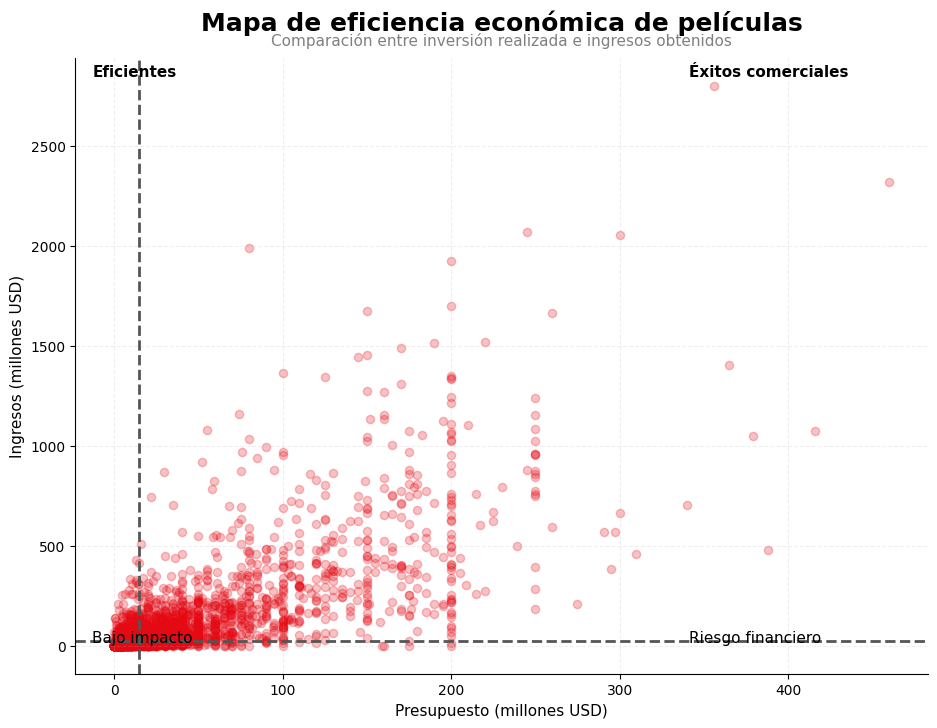

In [43]:
import matplotlib.pyplot as plt


# Convertir a millones USD
movies_finanzas["budget_millones"] = movies_finanzas["budget"] / 1_000_000
movies_finanzas["revenue_millones"] = movies_finanzas["revenue"] / 1_000_000


# Medianas
mediana_budget = movies_finanzas["budget_millones"].median()
mediana_revenue = movies_finanzas["revenue_millones"].median()


# Crear gráfico
plt.figure(figsize=(11,8))


# Puntos
plt.scatter(
    movies_finanzas["budget_millones"],
    movies_finanzas["revenue_millones"],
    color="#E50914",
    alpha=0.25,
    s=35
)


# Líneas divisorias
plt.axvline(
    mediana_budget,
    linestyle="--",
    linewidth=2,
    color="#555555"
)

plt.axhline(
    mediana_revenue,
    linestyle="--",
    linewidth=2,
    color="#555555"
)


# Título
plt.title(
    "Mapa de eficiencia económica de películas",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.text(
    0.5,
    1.02,
    "Comparación entre inversión realizada e ingresos obtenidos",
    ha="center",
    transform=plt.gca().transAxes,
    fontsize=11,
    color="gray"
)


# Etiquetas de ejes
plt.xlabel(
    "Presupuesto (millones USD)",
    fontsize=11
)

plt.ylabel(
    "Ingresos (millones USD)",
    fontsize=11
)


# Etiquetas pequeñas de cuadrantes
plt.text(
    0.02,
    0.97,
    "Eficientes",
    transform=plt.gca().transAxes,
    fontsize=11,
    fontweight="bold"
)

plt.text(
    0.72,
    0.97,
    "Éxitos comerciales",
    transform=plt.gca().transAxes,
    fontsize=11,
    fontweight="bold"
)

plt.text(
    0.02,
    0.05,
    "Bajo impacto",
    transform=plt.gca().transAxes,
    fontsize=11
)

plt.text(
    0.72,
    0.05,
    "Riesgo financiero",
    transform=plt.gca().transAxes,
    fontsize=11
)


# Diseño
plt.grid(
    linestyle="--",
    alpha=0.2
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


plt.show()

* Hallazgo:  
El análisis financiero se realizó sobre 3.540 películas con información disponible de presupuesto e ingresos. Se observa que existe una tendencia positiva entre inversión e ingresos, donde las producciones con mayores presupuestos suelen alcanzar mayores ingresos. Sin embargo, también se identifican casos de películas con inversiones elevadas que no logran ingresos proporcionales, representando posibles riesgos financieros. Por otro lado, algunas producciones de menor inversión alcanzan ingresos elevados, destacando por su eficiencia económica.  

* Justificacion:  
Se utilizó un mapa de cuadrantes debido a que permite analizar simultáneamente dos variables financieras relevantes: el presupuesto invertido y los ingresos obtenidos por cada película. La posición de cada contenido dentro del gráfico facilita identificar distintos comportamientos económicos, como producciones eficientes con baja inversión y altos ingresos, éxitos comerciales con grandes inversiones y posibles riesgos financieros cuando una producción requiere una alta inversión sin generar ingresos proporcionales. Además, la conversión de las variables a millones de dólares mejora la interpretación para un público no técnico, permitiendo comunicar los resultados de manera más clara y orientada a la toma de decisiones.

# **CONCLUSION DEL EDA**

El análisis exploratorio permitió identificar patrones relevantes dentro del catálogo. Se observó una fuerte presencia de contenidos en inglés, predominancia de ciertos géneros como drama y comedia, y diferencias entre películas y series respecto a popularidad y valoración. Además, el análisis financiero evidenció que mayores inversiones suelen asociarse con mayores ingresos, aunque existen casos donde producciones con menor presupuesto logran resultados eficientes. En conjunto, los resultados muestran que la popularidad, valoración e inversión económica son factores relacionados, pero no determinan completamente el éxito de un contenido.